# C01 — linear regression as a neural network

STAT41140: AI for weather and climate

This notebook builds the smallest possible learning system — one weight, one bias — and fits it by
gradient descent. Everything later in the module is this loop with more parameters.

What we do, in order:

1. make a tiny temperature data set
2. write down the model and the loss
3. work out the exact answer, so we know what success looks like
4. run gradient descent — **and watch it fail**
5. diagnose the failure by looking at the loss surface
6. fix it by centring the data, and see the fix work
7. extend to several inputs, and to classification

**Notation.** `X` is the input (what the slides call $x$), `y` the observed target, `y_pred` the
prediction $\hat{y}$, `w` the weight, `b` the bias, `lr` the learning rate $\alpha$.

**One thing to fix in your head now:** we *minimise* the mean squared error, and we *report* the
root mean squared error, because RMSE is in degrees Celsius and MSE is in degrees squared. Same
minimum, different numbers, and the gradients belong to the MSE.

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Plot settings chosen so the figures are readable when projected.
plt.rcParams.update({
    "figure.figsize": (6.5, 4.5),
    "figure.dpi": 110,
    "savefig.dpi": 200,
    "savefig.bbox": "tight",
    "font.size": 12,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

FIGS = Path("figs")
FIGS.mkdir(exist_ok=True)

np.set_printoptions(precision=4, suppress=True)

## 1. A very small data set

Five pairs of temperatures: `X` is the temperature now, `y` is the temperature six hours later.

Note what this actually is: predicting a temperature from the temperature six hours earlier is
**persistence**, the baseline that every operational forecast — AI or physical — has to beat. So
this toy is not as toy as it looks.

In [32]:
np.random.seed(100) 

X = 15 + np.random.rand(5)          # temperature now, degC
y = X + np.random.rand(5) * 0.3     # temperature in 6 h, degC

print("X (temperature now, degC)   :", np.round(X, 2))
print("y (temperature +6 h, degC)  :", np.round(y, 2))
print(' 1 ')
print("mean of X:", round(X.mean(), 3), " spread of X:", round(X.max() - X.min(), 3))

X (temperature now, degC)   : [15.54 15.28 15.42 15.84 15.  ]
y (temperature +6 h, degC)  : [15.58 15.48 15.67 15.89 15.18]
 1 
mean of X: 15.419  spread of X: 0.84


Look hard at that last line. Every value of `X` sits close to 15.4, and they span less than one
degree. That single fact is going to cause us a great deal of trouble in section 5, and it is the
main thing this notebook is about.

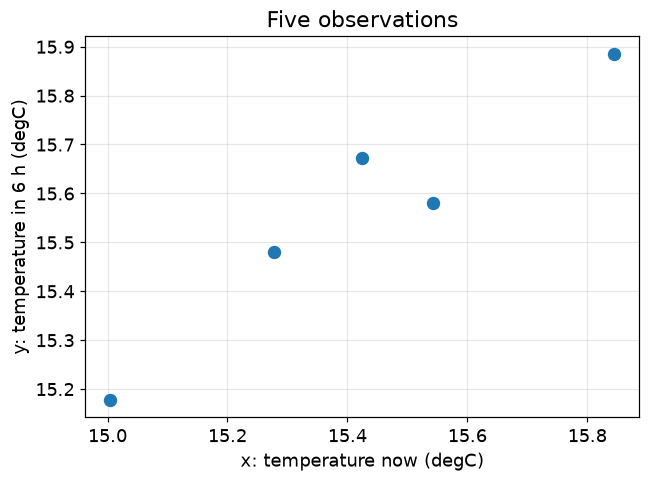

In [3]:
fig, ax = plt.subplots()
ax.scatter(X, y, s=60, zorder=3)
ax.set_xlabel("x: temperature now (degC)")
ax.set_ylabel("y: temperature in 6 h (degC)")
ax.set_title("Five observations")
fig.savefig(FIGS / "fig01_data.png")
plt.show()

## 2. The model

$$\hat{y} = b + w x$$

One weight, one bias. In neural network language this is a single neuron with an identity
activation function — we come back to that in section 10.

In [4]:
def predict(X, w, b):
    '''Forward pass: the model's prediction y_hat.'''
    return w * X + b

## 3. The loss

The residual for observation $i$ is $r_i = y_i - \hat{y}_i$. We choose $w$ and $b$ to make the
residuals small, measured by

$$\text{MSE} = \frac{1}{n}\sum_i r_i^2, \qquad \text{RMSE} = \sqrt{\text{MSE}}$$

We minimise MSE and report RMSE. The residual sum of squares $\sum_i r_i^2$ has the same minimiser;
it is just $n \times \text{MSE}$.

In [5]:
def mse(y_true, y_pred):
    '''The quantity we minimise. Units: degC squared.'''
    return ((y_true - y_pred) ** 2).mean()

def rmse(y_true, y_pred):
    '''The quantity we report. Units: degC.'''
    return np.sqrt(mse(y_true, y_pred))

### Trying a few guesses by hand

This is the calculation we do on the board. Pick some values of $b$ and $w$, work out the
residuals, square them, add them up. Lower is better.

In [6]:
for b, w in [(1, 1), (5, 0.5), (3, 0.8)]:
    r = y - predict(X, w, b)
    print(f"b={b:>3}, w={w:>4}:  residuals = {np.round(r, 3)}   "
          f"sum of squares = {np.sum(r**2):8.3f}   RMSE = {rmse(y, predict(X, w, b)):.3f} degC")

b=  1, w=   1:  residuals = [-0.964 -0.799 -0.752 -0.959 -0.827]   sum of squares =    3.737   RMSE = 0.864 degC
b=  5, w= 0.5:  residuals = [2.808 2.84  2.96  2.963 2.675]   sum of squares =   40.652   RMSE = 2.851 degC
b=  3, w= 0.8:  residuals = [0.145 0.257 0.333 0.21  0.173]   sum of squares =    0.272   RMSE = 0.233 degC


Those residuals are awkward numbers to square in front of a class. Hold that thought too — the fix
in section 7 makes the board arithmetic much friendlier as a side effect.

## 4. The exact answer

For *this* model we can skip gradient descent entirely. Setting the two partial derivatives of the
loss to zero and solving gives the ordinary least squares solution in closed form. We compute it
here not because we need it, but because it tells us what number gradient descent is supposed to
arrive at.

In [7]:
def least_squares(X, y):
    '''Exact minimiser of the squared-error loss, via the normal equations.'''
    D = np.column_stack([np.ones_like(X), X])        # design matrix [1, x]
    b_exact, w_exact = np.linalg.lstsq(D, y, rcond=None)[0]
    return w_exact, b_exact

w_exact, b_exact = least_squares(X, y)
print(f"exact solution:  w = {w_exact:.4f},  b = {b_exact:.4f}")
print(f"lowest possible RMSE: {rmse(y, predict(X, w_exact, b_exact)):.4f} degC")

exact solution:  w = 0.8029,  b = 3.1791
lowest possible RMSE: 0.0661 degC


**So why do we bother with gradient descent?** Because that closed form only exists because the
model is linear in its parameters, and it needs a matrix inverse. AIFS has of the order of $10^8$
parameters and no closed form. Gradient descent is the method that survives to the end of the
module; linear regression is just the one case where we can check its answer exactly.

## 5. Gradient descent — first attempt

The gradients of the MSE are

$$\frac{\partial L}{\partial w} = \frac{2}{n}\sum_i (\hat{y}_i - y_i)\, x_i,
\qquad
\frac{\partial L}{\partial b} = \frac{2}{n}\sum_i (\hat{y}_i - y_i)$$

and the update rule is $w \leftarrow w - \alpha \,\partial L/\partial w$, likewise for $b$.

In [8]:
def compute_gradients(X, y, w, b):
    '''Partial derivatives of the MEAN squared error with respect to w and b.'''
    error = predict(X, w, b) - y          # note the sign: prediction minus observation
    dw = 2 * (error * X).mean()
    db = 2 * error.mean()
    return dw, db


def train(X, y, w=0.0, b=0.0, lr=0.01, epochs=100, verbose_every=None):
    '''Plain (batch) gradient descent. Returns the history of w, b and RMSE.'''
    hist = {"w": [], "b": [], "rmse": []}
    for epoch in range(epochs):
        dw, db = compute_gradients(X, y, w, b)
        w -= lr * dw
        b -= lr * db
        hist["w"].append(w)
        hist["b"].append(b)
        hist["rmse"].append(rmse(y, predict(X, w, b)))
        if verbose_every and epoch % verbose_every == 0:
            print(f"Epoch {epoch:>6}, RMSE: {hist['rmse'][-1]:10.4f}, w: {w:8.4f}, b: {b:8.4f}")
    return w, b, hist

### Attempt 1: a learning rate of 0.01

A perfectly sensible-looking first guess.

In [9]:
np.seterr(over="ignore", invalid="ignore")   # we are about to overflow on purpose

w_bad, b_bad, hist_bad = train(X, y, w=0.0, b=0.0, lr=0.01, epochs=10, verbose_every=1)

Epoch      0, RMSE:    58.7650, w:   4.7994, b:   0.3112
Epoch      1, RMSE:   221.9290, w: -13.3257, b:  -0.8639
Epoch      2, RMSE:   838.1269, w:  55.1246, b:   3.5740
Epoch      3, RMSE:  3165.2321, w: -203.3818, b: -13.1858
Epoch      4, RMSE: 11953.6716, w: 772.8818, b:  50.1086
Epoch      5, RMSE: 45143.6931, w: -2914.0309, b: -188.9261
Epoch      6, RMSE: 170487.6210, w: 11009.7961, b: 713.8016
Epoch      7, RMSE: 643855.8054, w: -41574.2967, b: -2695.3988
Epoch      8, RMSE: 2431556.5892, w: 157012.3998, b: 10179.6328
Epoch      9, RMSE: 9182906.1671, w: -592961.0980, b: -38443.6268


It has exploded. Not converged slowly — **diverged**, to numbers no computer can represent, within
a handful of steps.

> **Question for the room:** the update rule only ever moves *downhill*. How can taking a downhill
> step make the loss larger?

The answer is that the gradient tells you the downhill *direction*, not how far to go. If the
surface curves sharply, a step of length $\alpha \times$ gradient can overshoot the bottom and land
higher up the far side. Each overshoot is bigger than the last.

### Attempt 2: a much smaller learning rate

Start from $w = 2$, $b = 2$ with $\alpha = 0.001$, and run ten epochs.

In [10]:
w_gd, b_gd, hist_gd = train(X, y, w=2.0, b=2.0, lr=0.001, epochs=10, verbose_every=1)

Epoch      0, RMSE:     9.0277, w:   1.4669, b:   1.9654
Epoch      1, RMSE:     4.7160, w:   1.1885, b:   1.9474
Epoch      2, RMSE:     2.4641, w:   1.0431, b:   1.9380
Epoch      3, RMSE:     1.2885, w:   0.9671, b:   1.9330
Epoch      4, RMSE:     0.6757, w:   0.9274, b:   1.9305
Epoch      5, RMSE:     0.3579, w:   0.9067, b:   1.9291
Epoch      6, RMSE:     0.1962, w:   0.8959, b:   1.9284
Epoch      7, RMSE:     0.1186, w:   0.8902, b:   1.9281
Epoch      8, RMSE:     0.0859, w:   0.8873, b:   1.9279
Epoch      9, RMSE:     0.0746, w:   0.8857, b:   1.9278


That looks like a success. The loss falls smoothly from about 9 to about 0.07 degrees and then
flattens off, which is exactly the shape of curve we are taught to look for.

It is not a success. Compare where it stopped with the exact answer from section 4:

In [11]:
print(f"{'':22s} {'w':>10s} {'b':>10s} {'RMSE':>10s}")
print(f"{'gradient descent':22s} {w_gd:10.4f} {b_gd:10.4f} {rmse(y, predict(X, w_gd, b_gd)):10.4f}")
print(f"{'exact solution':22s} {w_exact:10.4f} {b_exact:10.4f} {rmse(y, predict(X, w_exact, b_exact)):10.4f}")

                                w          b       RMSE
gradient descent           0.8857     1.9278     0.0746
exact solution             0.8029     3.1791     0.0661


The bias is wrong by more than 1.2 degrees and has barely moved from where it started. The RMSE is
close to the best possible, which is why the loss curve looked convincing — but the *parameters*
are nowhere near right.

Perhaps it just needs longer. Let us give it a hundred thousand epochs.

In [12]:
w_long, b_long, hist_long = train(X, y, w=2.0, b=2.0, lr=0.001, epochs=100_000)

for n in [10, 100, 1_000, 10_000, 100_000]:
    print(f"after {n:>7,} epochs:  w = {hist_long['w'][n-1]:.4f},  b = {hist_long['b'][n-1]:.4f}")
print(f"{'exact:':>21s}  w = {w_exact:.4f},  b = {b_exact:.4f}")

after      10 epochs:  w = 0.8857,  b = 1.9278
after     100 epochs:  w = 0.8840,  b = 1.9277
after   1,000 epochs:  w = 0.8840,  b = 1.9285
after  10,000 epochs:  w = 0.8835,  b = 1.9358
after 100,000 epochs:  w = 0.8789,  b = 2.0064
               exact:  w = 0.8029,  b = 3.1791


A hundred thousand epochs on five data points, and it is still crawling. Something is badly wrong,
and it is not the code.

## 6. Diagnosis: look at the loss surface

The loss is a function of two numbers, so we can simply draw it. Plot it over a range wide enough
to contain both the starting point and the true minimum.

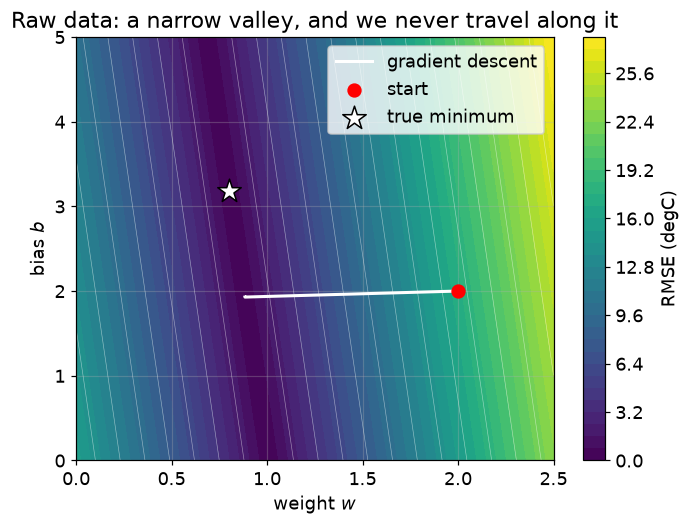

In [13]:
def loss_surface(X, y, w_range, b_range):
    W, B = np.meshgrid(w_range, b_range)
    Z = np.array([[rmse(y, predict(X, w, b)) for w in w_range] for b in b_range])
    return W, B, Z


w_range = np.linspace(0.0, 2.5, 200)
b_range = np.linspace(0.0, 5.0, 200)
W, B, Z = loss_surface(X, y, w_range, b_range)

fig, ax = plt.subplots(figsize=(7, 5))
cs = ax.contourf(W, B, Z, levels=40, cmap="viridis")
fig.colorbar(cs, ax=ax, label="RMSE (degC)")
ax.contour(W, B, Z, levels=15, colors="white", linewidths=0.4, alpha=0.5)
path_w = [2.0] + hist_long["w"][:2000]      # prepend the starting point
path_b = [2.0] + hist_long["b"][:2000]
ax.plot(path_w, path_b, color="white", lw=2, label="gradient descent")
ax.scatter([2.0], [2.0], color="red", s=70, zorder=5, label="start")
ax.scatter([w_exact], [b_exact], color="white", marker="*", s=260,
           edgecolor="black", zorder=6, label="true minimum")
ax.set_xlabel("weight $w$")
ax.set_ylabel("bias $b$")
ax.set_title("Raw data: a narrow valley, and we never travel along it")
ax.legend(loc="upper right")
fig.savefig(FIGS / "fig02_loss_surface_raw.png")
plt.show()

There is the problem. The loss surface is not a bowl, it is a **canyon** running diagonally across
the $(w, b)$ plane. Gradient descent falls into the canyon almost immediately — that is the fast
drop in the loss curve — and then has to inch along the floor, because along the floor the surface
is almost flat and so the gradient is almost zero.

Why a canyon? Because every $x$ is close to 15.4. Raising $w$ by $0.01$ and lowering $b$ by
$0.154$ leaves every prediction essentially unchanged, so a whole line of $(w, b)$ pairs fits the
data almost equally well. The parameters are nearly redundant.

We can put a number on it. The curvature of the loss is described by the Hessian; the ratio of its
largest to smallest eigenvalue — the **condition number** — measures how stretched the valley is.

In [14]:
def conditioning(X):
    D = np.column_stack([np.ones_like(X), X])
    H = 2 * D.T @ D / len(X)                 # Hessian of the MSE
    ev = np.linalg.eigvalsh(H)
    return ev, ev[-1] / ev[0], 2 / ev[-1]    # eigenvalues, condition number, largest stable lr

ev, cond, lr_max = conditioning(X)
print(f"Hessian eigenvalues : {ev[0]:.3e}  and  {ev[-1]:.3e}")
print(f"condition number    : {cond:,.0f}")
print(f"largest stable lr   : {lr_max:.5f}")

Hessian eigenvalues : 6.502e-04  and  4.777e+02
condition number    : 734,660
largest stable lr   : 0.00419


Two things follow immediately, and both match what we saw:

- any learning rate above about $0.004$ diverges, which is why $\alpha = 0.01$ exploded;
- below that, progress along the flat direction is slower than progress across the valley by
  roughly the condition number, so convergence takes of the order of that many epochs.

**This is not a quirk of a toy problem.** Real meteorological inputs are far worse: geopotential
height is of order $50{,}000\ \text{m}^2\,\text{s}^{-2}$ while specific humidity is of order
$0.01\ \text{kg}\,\text{kg}^{-1}$. Feed those to a network raw and you get the same canyon, with
seven orders of magnitude in it.

## 7. The fix: centre the data

Work in **anomalies** — departures from a reference value — rather than absolute temperatures. Take
15 °C as the reference. This is what meteorologists do anyway, and it costs nothing: the model is
the same model, just written about a different origin.

In [15]:
REF = 15.0
Xa = X - REF          # temperature anomaly now, degC
ya = y - REF          # temperature anomaly in 6 h, degC

print("Xa:", np.round(Xa, 2))
print("ya:", np.round(ya, 2))

ev_a, cond_a, lr_max_a = conditioning(Xa)
print()
print(f"condition number  raw: {cond:>12,.0f}      centred: {cond_a:>10,.1f}")
print(f"largest stable lr raw: {lr_max:>12.5f}      centred: {lr_max_a:>10.4f}")

Xa: [0.54 0.28 0.42 0.84 0.  ]
ya: [0.58 0.48 0.67 0.89 0.18]

condition number  raw:      734,660      centred:       18.2
largest stable lr raw:      0.00419      centred:     0.8418


Four decimal places' worth of ill-conditioning, gone. Now we can use a learning rate a hundred
times larger.

In [16]:
w_a, b_a, hist_a = train(Xa, ya, w=0.0, b=0.0, lr=0.5, epochs=100, verbose_every=20)

w_exact_a, b_exact_a = least_squares(Xa, ya)
print()
print(f"after 100 epochs : w = {w_a:.4f},  b = {b_a:.4f}")
print(f"exact (anomalies): w = {w_exact_a:.4f},  b = {b_exact_a:.4f}")

Epoch      0, RMSE:     0.1993, w:   0.2966, b:   0.5590
Epoch     20, RMSE:     0.0771, w:   0.6613, b:   0.2859
Epoch     40, RMSE:     0.0669, w:   0.7662, b:   0.2389
Epoch     60, RMSE:     0.0662, w:   0.7934, b:   0.2267
Epoch     80, RMSE:     0.0661, w:   0.8004, b:   0.2235

after 100 epochs : w = 0.8022,  b = 0.2227
exact (anomalies): w = 0.8029,  b = 0.2224


One hundred epochs, and it agrees with the exact answer to four decimal places. Compare that with
a hundred thousand epochs on the raw data that never got there.

The fitted parameters are in anomaly units. Converting back to absolute temperatures is one line of
algebra: if $\hat{y} - 15 = b' + w(x - 15)$ then $\hat{y} = \left[b' + 15(1 - w)\right] + w x$, so
the weight is unchanged and only the bias moves.

In [17]:
w_back = w_a
b_back = b_a + REF * (1 - w_a)

print(f"{'':26s} {'w':>10s} {'b':>10s}")
print(f"{'gradient descent (centred)':26s} {w_back:10.4f} {b_back:10.4f}")
print(f"{'exact (raw data)':26s} {w_exact:10.4f} {b_exact:10.4f}")
print()
print(f"RMSE of the recovered model: {rmse(y, predict(X, w_back, b_back)):.4f} degC")

                                    w          b
gradient descent (centred)     0.8022     3.1896
exact (raw data)               0.8029     3.1791

RMSE of the recovered model: 0.0661 degC


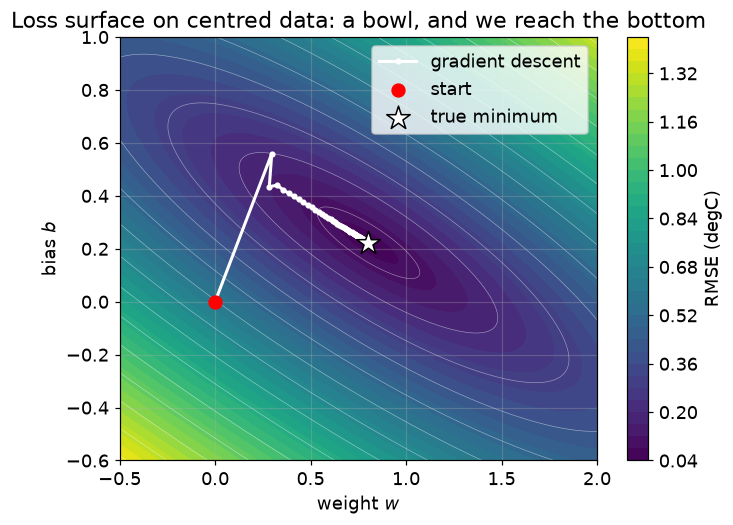

In [18]:
w_range_a = np.linspace(-0.5, 2.0, 200)
b_range_a = np.linspace(-0.6, 1.0, 200)
Wa, Ba, Za = loss_surface(Xa, ya, w_range_a, b_range_a)

fig, ax = plt.subplots(figsize=(7, 5))
cs = ax.contourf(Wa, Ba, Za, levels=40, cmap="viridis")
fig.colorbar(cs, ax=ax, label="RMSE (degC)")
ax.contour(Wa, Ba, Za, levels=15, colors="white", linewidths=0.4, alpha=0.5)
ax.plot([0.0] + hist_a["w"], [0.0] + hist_a["b"], color="white", lw=2, marker="o", ms=3,
        label="gradient descent")
ax.scatter([0.0], [0.0], color="red", s=70, zorder=5, label="start")
ax.scatter([w_exact_a], [b_exact_a], color="white", marker="*", s=260,
           edgecolor="black", zorder=6, label="true minimum")
ax.set_xlabel("weight $w$")
ax.set_ylabel("bias $b$")
ax.set_title("Loss surface on centred data: a bowl, and we reach the bottom")
ax.legend(loc="upper right")
fig.savefig(FIGS / "fig03_loss_surface_centred.png")
plt.show()

Same data, same model, same algorithm. The only change is where we put the origin — and the
optimisation went from impossible to trivial.

**This is the whole content of the feature-scaling slide.** Standardising inputs is not tidiness;
it is what turns a canyon into a bowl. In practice you will usually subtract the mean and divide by
the standard deviation rather than subtracting 15, and you compute both statistics **on the
training set only** — using the whole data set leaks information from the test set into training.

## 8. The learning rate

Now that the surface is well behaved we can see what $\alpha$ actually does. Three runs on the
centred data: one too small, one about right, one too large.

In [19]:
settings = [(0.01, "too small"), (0.5, "about right"), (1.05, "too large")]
runs = {}
for lr, label in settings:
    _, _, h = train(Xa, ya, w=0.0, b=0.0, lr=lr, epochs=60)
    runs[label] = h
    print(f"lr = {lr:<5} ({label:11s}): RMSE after 60 epochs = {h['rmse'][-1]:.4g}")

print(f"\nlargest stable learning rate here: {lr_max_a:.4f}")

lr = 0.01  (too small  ): RMSE after 60 epochs = 0.2147
lr = 0.5   (about right): RMSE after 60 epochs = 0.06617
lr = 1.05  (too large  ): RMSE after 60 epochs = 1.726e+10

largest stable learning rate here: 0.8418


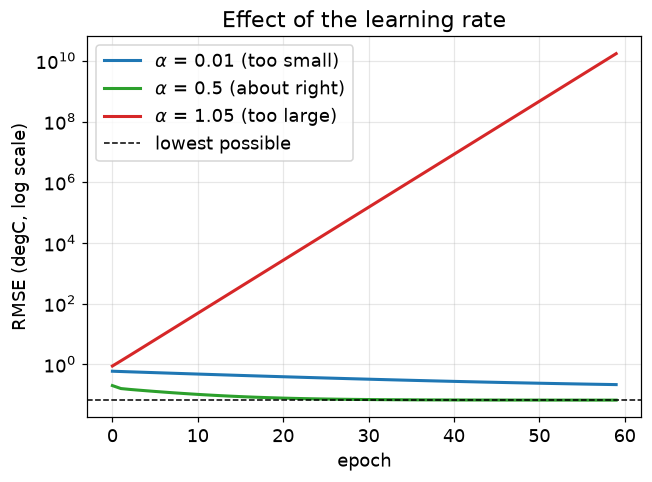

In [20]:
fig, ax = plt.subplots()
for (lr, label), colour in zip(settings, ["tab:blue", "tab:green", "tab:red"]):
    ax.plot(runs[label]["rmse"], color=colour, lw=2, label=f"$\\alpha$ = {lr} ({label})")
ax.axhline(rmse(ya, predict(Xa, w_exact_a, b_exact_a)), color="black", ls="--", lw=1,
           label="lowest possible")
ax.set_yscale("log")
ax.set_xlabel("epoch")
ax.set_ylabel("RMSE (degC, log scale)")
ax.set_title("Effect of the learning rate")
ax.legend()
fig.savefig(FIGS / "fig04_learning_rate.png")
plt.show()

Note the log scale on the vertical axis — without it the diverging run swamps everything else.
Too small and you creep; too large and the loss climbs away; in between there is a wide range that
works fine.

## 9. The fitted line

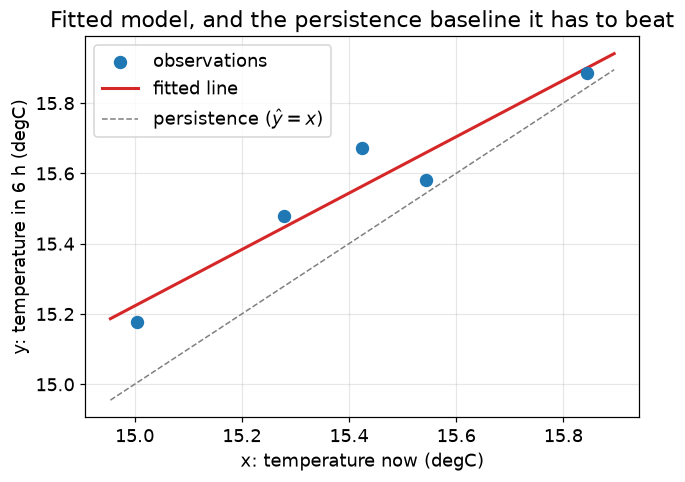

fitted model  RMSE: 0.0661 degC
persistence   RMSE: 0.1641 degC


In [21]:
fig, ax = plt.subplots()
ax.scatter(X, y, s=60, zorder=3, label="observations")
xs = np.linspace(X.min() - 0.05, X.max() + 0.05, 100)
ax.plot(xs, predict(xs, w_back, b_back), color="tab:red", lw=2, label="fitted line")
ax.plot(xs, xs, color="grey", ls="--", lw=1, label="persistence ($\\hat{y} = x$)")
ax.set_xlabel("x: temperature now (degC)")
ax.set_ylabel("y: temperature in 6 h (degC)")
ax.set_title("Fitted model, and the persistence baseline it has to beat")
ax.legend()
fig.savefig(FIGS / "fig05_fit.png")
plt.show()

print(f"fitted model  RMSE: {rmse(y, predict(X, w_back, b_back)):.4f} degC")
print(f"persistence   RMSE: {rmse(y, X):.4f} degC")

Always score a model against a baseline. Here the fitted line beats persistence, but on five points
that is not evidence of much — which is itself the lesson.

## 10. Linear regression *is* a neural network

Everything above can be redrawn as a single **neuron**:

```
                 w
    x  ─────────────────▶  ( Σ )  ─────▶  activation  ─────▶  ŷ
                             ▲
                    b  ──────┘
```

Multiply each input by a weight, add them up, add a bias, then pass the result through an
activation function. That is the entire computation.

- activation = identity  →  **linear regression** (sections 1–9)
- activation = sigmoid   →  **logistic regression** (section 12)
- stack many of these, with a nonlinear activation between the layers, and you have a neural
  network. Nothing else changes: same loss, same gradients, same update rule.

Written in code, the whole of this lecture is four lines.

In [22]:
def identity(z):
    return z

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def neuron(x, w, b, activation=identity):
    '''A single neuron: weighted sum, add bias, apply activation.'''
    return activation(np.dot(x, w) + b)


# Check it reproduces the linear model we just fitted.
print("neuron with identity activation:", np.round(neuron(X, w_back, b_back), 3))
print("predict()                      :", np.round(predict(X, w_back, b_back), 3))

neuron with identity activation: [15.659 15.446 15.563 15.9   15.227]
predict()                      : [15.659 15.446 15.563 15.9   15.227]


## 11. Extension 1: more than one input

Nothing structural changes. The weight becomes a vector, the dot product does the summing, and the
gradient with respect to each weight has the same form as before.

We now use a larger synthetic data set so the results mean something: 60 days of temperature and
rainfall, predicting tomorrow's temperature.

In [23]:
rng = np.random.default_rng(42)
n = 60

temp_today = 15 + 4 * rng.standard_normal(n)          # degC,  spread of order 4
rain_today = np.abs(2 * rng.standard_normal(n))       # mm,    spread of order 2

# Truth: tomorrow is mostly like today, a little cooler if it rained.
temp_tomorrow = 3.0 + 0.80 * temp_today - 0.50 * rain_today + 1.5 * rng.standard_normal(n)

F = np.column_stack([temp_today, rain_today])         # design matrix, n x 2
print("feature means :", np.round(F.mean(axis=0), 2))
print("feature sds   :", np.round(F.std(axis=0), 2))

feature means : [15.26  1.28]
feature sds   : [3.12 0.91]


The two inputs have different means and different spreads, so — by section 6 — we standardise
before fitting. We compute the mean and standard deviation on the training set only.

In [24]:
# Chronological split: for weather data you must NOT split at random, because
# consecutive days are correlated and a random split leaks the answer.
n_train = 45
F_train, F_test = F[:n_train], F[n_train:]
t_train, t_test = temp_tomorrow[:n_train], temp_tomorrow[n_train:]

mu, sd = F_train.mean(axis=0), F_train.std(axis=0)     # training statistics only
Fs_train = (F_train - mu) / sd
Fs_test = (F_test - mu) / sd


def train_multi(F, y, lr=0.1, epochs=400):
    w = np.zeros(F.shape[1])
    b = 0.0
    hist = []
    for _ in range(epochs):
        error = neuron(F, w, b) - y
        w -= lr * 2 * (F * error[:, None]).mean(axis=0)
        b -= lr * 2 * error.mean()
        hist.append(rmse(y, neuron(F, w, b)))
    return w, b, hist

w_multi, b_multi, hist_multi = train_multi(Fs_train, t_train, lr=0.1, epochs=400)

print(f"weights (standardised units): temperature {w_multi[0]:.3f},  rainfall {w_multi[1]:.3f}")
print(f"bias                        : {b_multi:.3f}")
print()
print(f"training RMSE: {rmse(t_train, neuron(Fs_train, w_multi, b_multi)):.3f} degC")
print(f"test     RMSE: {rmse(t_test,  neuron(Fs_test,  w_multi, b_multi)):.3f} degC")
print(f"persistence test RMSE: {rmse(t_test, temp_today[n_train:]):.3f} degC")

weights (standardised units): temperature 2.432,  rainfall -0.439
bias                        : 14.463

training RMSE: 1.624 degC
test     RMSE: 1.148 degC
persistence test RMSE: 1.453 degC


Because the inputs are standardised, the weights are directly comparable: temperature matters
several times more than rainfall for tomorrow's temperature, which is the right answer and the
right way to read a fitted model.

With two inputs you can no longer plot the fit against one axis — the points would scatter off the
line and look broken. Plot **predicted against observed** instead. This works for any number of
inputs and it is the plot you will use for verification all term.

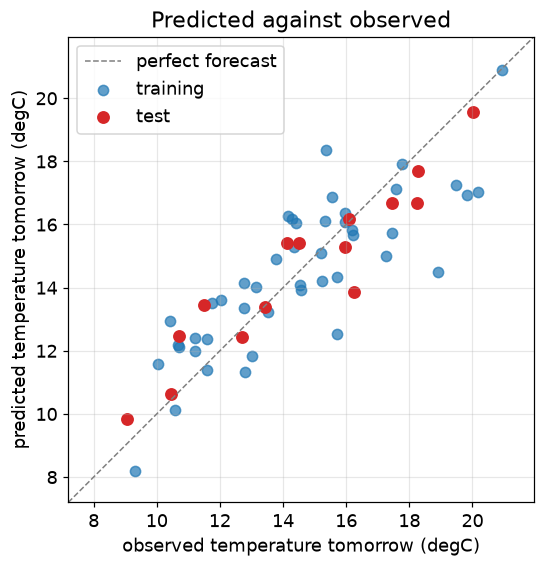

In [25]:
pred_train = neuron(Fs_train, w_multi, b_multi)
pred_test = neuron(Fs_test, w_multi, b_multi)

fig, ax = plt.subplots(figsize=(5.5, 5.5))
lims = [min(t_train.min(), pred_train.min()) - 1, max(t_train.max(), pred_train.max()) + 1]
ax.plot(lims, lims, color="grey", ls="--", lw=1, label="perfect forecast")
ax.scatter(t_train, pred_train, s=45, alpha=0.7, label="training")
ax.scatter(t_test, pred_test, s=55, color="tab:red", label="test")
ax.set_xlim(lims); ax.set_ylim(lims); ax.set_aspect("equal")
ax.set_xlabel("observed temperature tomorrow (degC)")
ax.set_ylabel("predicted temperature tomorrow (degC)")
ax.set_title("Predicted against observed")
ax.legend()
fig.savefig(FIGS / "fig06_pred_vs_obs.png")
plt.show()

## 12. Extension 2: classification

Suppose we only want to know whether tomorrow is **hot** ($y = 1$) or **cold** ($y = 0$). We need
the output to lie between 0 and 1 so we can read it as a probability, so we swap the identity
activation for a sigmoid — and, because the loss must match the output, we swap squared error for
**binary cross-entropy**:

$$L = -\frac{1}{n}\sum_i \Big[ y_i \log \hat{y}_i + (1 - y_i)\log(1 - \hat{y}_i) \Big]$$

Read it as: when $y_i = 1$ the loss is $-\log \hat{y}_i$, which is small when the predicted
probability is near 1 and grows without bound as it approaches 0; when $y_i = 0$ it is
$-\log(1 - \hat{y}_i)$, the mirror image. (This is the negative log-likelihood of a Bernoulli
distribution — the thread we pick up in the probabilistic forecasting lecture.)

The pleasing part: with a sigmoid output and cross-entropy loss, the gradient comes out **exactly
the same shape** as for linear regression. Nothing in the training loop changes.

In [26]:
def binary_cross_entropy(y_true, y_pred):
    eps = 1e-15                                   # stops us taking log(0)
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))


hot_train = (t_train > np.median(temp_tomorrow)).astype(float)
hot_test = (t_test > np.median(temp_tomorrow)).astype(float)


def train_logistic(F, y, lr=0.5, epochs=600):
    w = np.zeros(F.shape[1])
    b = 0.0
    hist = []
    for _ in range(epochs):
        error = neuron(F, w, b, sigmoid) - y       # identical form to the linear case
        w -= lr * (F * error[:, None]).mean(axis=0)
        b -= lr * error.mean()
        hist.append(binary_cross_entropy(y, neuron(F, w, b, sigmoid)))
    return w, b, hist


w_log, b_log, hist_log = train_logistic(Fs_train, hot_train, lr=0.5, epochs=600)

for e in [0, 50, 200, 599]:
    print(f"epoch {e:>3}: cross-entropy = {hist_log[e]:.4f}")
print()
print(f"weights: temperature {w_log[0]:.3f}, rainfall {w_log[1]:.3f};  bias {b_log:.3f}")

p_test = neuron(Fs_test, w_log, b_log, sigmoid)
print(f"test accuracy at a 0.5 threshold: {np.mean((p_test > 0.5) == hot_test):.2%}")

epoch   0: cross-entropy = 0.6500
epoch  50: cross-entropy = 0.4268
epoch 200: cross-entropy = 0.4217
epoch 599: cross-entropy = 0.4217

weights: temperature 2.372, rainfall -0.854;  bias -0.063
test accuracy at a 0.5 threshold: 86.67%


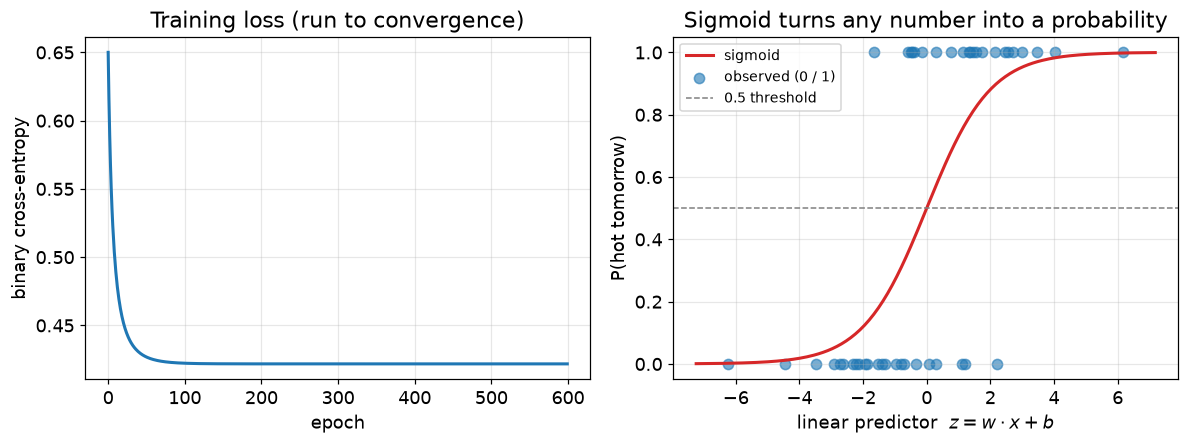

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

axes[0].plot(hist_log, lw=2)
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("binary cross-entropy")
axes[0].set_title("Training loss (run to convergence)")

# Plot against the linear predictor z = w.x + b, NOT against one feature:
# with two inputs, plotting against one of them makes the curve look ragged.
z_train = Fs_train @ w_log + b_log
zs = np.linspace(z_train.min() - 1, z_train.max() + 1, 200)
axes[1].plot(zs, sigmoid(zs), color="tab:red", lw=2, label="sigmoid")
axes[1].scatter(z_train, hot_train, s=45, alpha=0.6, label="observed (0 / 1)")
axes[1].axhline(0.5, color="grey", ls="--", lw=1, label="0.5 threshold")
axes[1].set_xlabel("linear predictor  $z = w\\cdot x + b$")
axes[1].set_ylabel("P(hot tomorrow)")
axes[1].set_title("Sigmoid turns any number into a probability")
axes[1].legend(fontsize=9)

fig.tight_layout()
fig.savefig(FIGS / "fig07_logistic.png")
plt.show()

Note that the prediction is a **probability**, not a label. Thresholding at 0.5 turns it into a
label and throws information away. Keeping the probability is the beginning of probabilistic
forecasting.

## 13. Try it yourself

1. In section 5, change the starting point to `w=0.0, b=0.0` and re-run with `lr=0.001`. Does the
   bias get any closer to 3.18? Why not?
2. Find, by bisection, the learning rate at which the raw-data run switches from converging to
   diverging. Compare it with `lr_max` from section 6.
3. In section 7, use the mean of `X` as the reference instead of 15. What happens to the condition
   number, and why is it the best possible choice?
4. In section 11, refit without standardising the features. How many epochs does it take, and what
   happens if you keep `lr = 0.1`?
5. In section 11, replace the chronological split with a random one. The test RMSE will improve.
   Explain why that improvement is an illusion.